# Quantum Fourier Transform
- https://github.com/Qiskit/textbook/blob/main/notebooks/ch-algorithms/quantum-fourier-transform.ipynb
- NC


The quantum Fourier transform (QFT) transforms between two bases, the computational (Z) basis, and the Fourier basis. The H-gate is the single-qubit QFT, and it transforms between the Z-basis states $|0\rangle$ and $|1\rangle$ to the X-basis states $|{+}\rangle$ and $|{-}\rangle$. In the same way, all multi-qubit states in the computational basis have corresponding states in the Fourier basis. The QFT is simply the function that transforms between these bases.

$$
|\text{State in Computational Basis}\rangle \quad \xrightarrow[]{\text{QFT}} \quad |\text{State in Fourier Basis}\rangle
$$




- $N=2^n$

- $QFT_N$ acting on the state $\vert x \rangle = \vert x_1\ldots x_n \rangle$ 

    $$
    \begin{aligned}
    QFT_N\vert x \rangle & = \frac{1}{\sqrt{N}} \sum_{y=0}^{N-1}\omega_N^{xy} \vert y \rangle 
    \\
    & = \frac{1}{\sqrt{N}} \sum_{y=0}^{N-1} e^{2 \pi i xy / 2^n} \vert y \rangle ~\text{since}\: \omega_N^{xy} = e^{2\pi i \frac{xy}{N}} \:\text{and}\: N = 2^n 
    \\
    & = \frac{1}{\sqrt{N}} \sum_{y=0}^{N-1} e^{2 \pi i \left(\sum_{k=1}^n y_k/2^k\right) x} \vert y_1 \ldots y_n \rangle \:\text{rewriting in fractional binary notation}\: y = y_1\ldots y_n, y/2^n = \sum_{k=1}^n y_k/2^k 
    \\
    & = \frac{1}{\sqrt{N}} \sum_{y=0}^{N-1} \prod_{k=1}^n e^{2 \pi i x y_k/2^k } \vert y_1 \ldots y_n \rangle \:\text{after expanding the exponential of a sum to a product of exponentials} 
    \\
    & = \frac{1}{\sqrt{N}} \bigotimes_{k=1}^n  \left(\vert0\rangle + e^{2 \pi i x /2^k } \vert1\rangle \right) \:\text{after rearranging the sum and products, and expanding} 
    \sum_{y=0}^{N-1} = \sum_{y_1=0}^{1}\sum_{y_2=0}^{1}\ldots\sum_{y_n=0}^{1} 
    \\
    & = \frac{1}{\sqrt{N}}
    \left(\vert0\rangle + e^{\frac{2\pi i}{2}x} \vert1\rangle\right) 
    \otimes
    \left(\vert0\rangle + e^{\frac{2\pi i}{2^2}x} \vert1\rangle\right) 
    \otimes  
    \ldots
    \otimes
    \left(\vert0\rangle + e^{\frac{2\pi i}{2^{n-1}}x} \vert1\rangle\right) 
    \otimes
    \left(\vert0\rangle + e^{\frac{2\pi i}{2^n}x} \vert1\rangle\right) 
    \end{aligned}
    $$


# QFT circuit

The steps to creating the circuit for $\vert y_3y_2y_1\rangle = QFT_8\vert x_3x_2x_1\rangle$ would be:

<ol>
<li> Apply a Hadamard gate to $\vert x_1 \rangle$

$$
|\psi_1\rangle = 
\vert x_3\rangle
\otimes
\vert x_2\rangle
\otimes
\frac{1}{\sqrt{2}}
\left[
\vert0\rangle + 
\exp\left(\frac{2\pi i}{2}x_1\right) 
\vert1\rangle\right]
$$

<li> Apply a $UROT_2$ gate to $\vert x_1\rangle$ depending on $\vert x_2\rangle$

$$
|\psi_2\rangle = 
\vert x_3\rangle
\otimes
\vert x_2\rangle
\otimes
\frac{1}{\sqrt{2}}
\left[
\vert0\rangle + 
\exp\left(
\frac{2\pi i}{2^2}x_2 + \frac{2\pi i}{2}x_1
\right) 
\vert1\rangle\right]
$$

<li> Apply a $UROT_3$ gate to $\vert x_1\rangle$ depending on $\vert x_3\rangle$

$$
|\psi_3\rangle = 
\vert x_3\rangle
\otimes
\vert x_2\rangle
\otimes
\frac{1}{\sqrt{2}}
\left[
\vert0\rangle + 
\exp\left(
\frac{2\pi i}{2^3}x_3 + \frac{2\pi i}{2^2}x_2 + \frac{2\pi i}{2}x_1
\right) 
\vert1\rangle\right]
$$

<li> Apply a Hadamard gate to $\vert x_2 \rangle$

$$
|\psi_4\rangle = 
\vert x_3\rangle
\otimes
\frac{1}{\sqrt{2}}
\left[
\vert0\rangle + 
\exp\left(
\frac{2\pi i}{2}x_2
\right) 
\vert1\rangle\right]
\otimes
\frac{1}{\sqrt{2}}
\left[
\vert0\rangle + 
\exp\left(
\frac{2\pi i}{2^3}x_3 + \frac{2\pi i}{2^2}x_2 + \frac{2\pi i}{2}x_1
\right) 
\vert1\rangle\right]
$$

<li> Apply a $UROT_2$ gate to $\vert x_2\rangle$ depending on $\vert x_3\rangle$

$$
|\psi_5\rangle = 
\vert x_3\rangle
\otimes
\frac{1}{\sqrt{2}}
\left[
\vert0\rangle + 
\exp\left(
\frac{2\pi i}{2^2}x_3 + \frac{2\pi i}{2}x_2
\right) 
\vert1\rangle\right]
\otimes
\frac{1}{\sqrt{2}}
\left[
\vert0\rangle + 
\exp\left(
\frac{2\pi i}{2^3}x_3 + \frac{2\pi i}{2^2}x_2 + \frac{2\pi i}{2}x_1
\right) 
\vert1\rangle\right]
$$

<li> Apply a Hadamard gate to $\vert x_3\rangle$

$$
|\psi_6\rangle = 
\frac{1}{\sqrt{2}}
\left[
\vert0\rangle + 
\exp\left(
\frac{2\pi i}{2}x_3
\right) 
\vert1\rangle\right]
\otimes
\frac{1}{\sqrt{2}}
\left[
\vert0\rangle + 
\exp\left(
\frac{2\pi i}{2^2}x_3 + \frac{2\pi i}{2}x_2
\right) 
\vert1\rangle\right]
\otimes
\frac{1}{\sqrt{2}}
\left[
\vert0\rangle + 
\exp\left(
\frac{2\pi i}{2^3}x_3 + \frac{2\pi i}{2^2}x_2 + \frac{2\pi i}{2}x_1
\right) 
\vert1\rangle\right]
$$


<li> Reverse the order of the qubits (in this case swap $y_1$ and $y_3$).

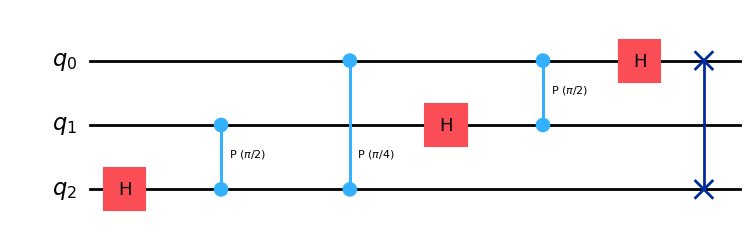

In [ ]:
from qiskit import QuantumCircuit
import matplotlib.pyplot as plt
from modexp import * 

n = 3
qc = QuantumCircuit(n)
qc.append(ModExpTools.myqft(n), range(n))
qc.decompose().draw('mpl')

# QPE



1. spectral theorem for unitary matrices U (NXN) says that exists an orthonormal basis of vectors along with complex numbers such that $U=\sum \lambda_k |\psi_k\rangle \langle \psi_k|$ with $\lambda_k=e^{2\pi i \theta_k}$. So that $U|\psi_k\rangle =e^{2\pi i \theta_k} |\psi_k\rangle$

2. input: unitary quantum circuit with state $|\psi_k\rangle$ eigenvector. output: approximatioj for its $\theta_k$.

3. approximation meaning: $2\pi\theta$ is represented on the complex unit circle. We can consider $\theta\sim\frac{y}{2^m}$ where $y\in \{0,1,\dots , 2^m-1 \}$.


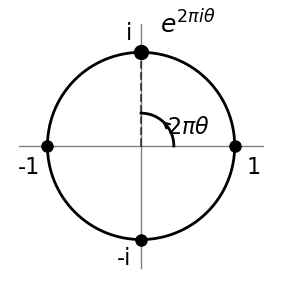

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Crea la figura con sfondo bianco
fig, ax = plt.subplots(1, 1, figsize=(3, 3), facecolor='white')
ax.set_facecolor('white')

# Cerchio unitario
theta_circle = np.linspace(0, 2*np.pi, 1000)
x_circle = np.cos(theta_circle)
y_circle = np.sin(theta_circle)
ax.plot(x_circle, y_circle, 'k-', linewidth=2)

# Assi cartesiani
ax.plot([-1.3, 1.3], [0, 0], 'k-', linewidth=1, alpha=0.5)
ax.plot([0, 0], [-1.3, 1.3], 'k-', linewidth=1, alpha=0.5)

# Angolo theta (modifica questo valore per cambiare la posizione del punto)
theta = 0.25  # frazione di 2π
angle_rad = 2 * np.pi * theta

# Punto e^(2πiθ)
point_x = np.cos(angle_rad)
point_y = np.sin(angle_rad)
ax.plot(point_x, point_y, 'ko', markersize=10, zorder=5)

# Linea tratteggiata dal punto all'origine
ax.plot([0, point_x], [0, point_y], 'k--', linewidth=1.5, alpha=0.6)

# Arco dell'angolo
theta_arc = np.linspace(0, angle_rad, 50)
r_arc = 0.35
x_arc = r_arc * np.cos(theta_arc)
y_arc = r_arc * np.sin(theta_arc)
ax.plot(x_arc, y_arc, 'k-', linewidth=2)

# Freccia sull'arco (opzionale)
mid_idx = len(theta_arc) // 2
ax.annotate('', xy=(x_arc[mid_idx+2], y_arc[mid_idx+2]), 
            xytext=(x_arc[mid_idx], y_arc[mid_idx]),
            arrowprops=dict(arrowstyle='->', lw=1.5, color='black'))

# Labels
ax.text(point_x + 0.2, point_y + 0.15, r'$e^{2\pi i\theta}$', 
        fontsize=18, ha='left', va='bottom')
ax.text(0.5, 0.2, r'$2\pi\theta$', fontsize=16, ha='center', va='center')

# Labels degli assi
ax.text(1.2, -0.1, '1', fontsize=16, ha='center', va='top')
ax.text(-1.2, -0.1, '-1', fontsize=16, ha='center', va='top')
ax.text(-0.1, 1.2, 'i', fontsize=16, ha='right', va='center')
ax.text(-0.1, -1.2, '-i', fontsize=16, ha='right', va='center')

# Punti sugli assi
ax.plot([1, -1], [0, 0], 'ko', markersize=8)
ax.plot([0, 0], [1, -1], 'ko', markersize=8)

# Impostazioni finali
ax.set_xlim(-1.4, 1.4)
ax.set_ylim(-1.4, 1.4)
ax.set_aspect('equal')
ax.axis('off')

plt.tight_layout()


4. phase kickback: one considers a unitary controlled gate. 


<img src="imgs/Screenshot 2026-02-19 alle 09.17.33.png" width="300" height="200" alt="carry">


- $\ket{\pi_0} = \ket{\phi}\ket{0}$
- $\ket{\pi_1} = \frac 1 {\sqrt 2}(\ket{\phi}\ket{0}+\ket{\phi}\ket{1})$
- $\ket{\pi_2} = \frac 1 {\sqrt 2}(\ket{\phi}\ket{0}+U\ket{\phi}\ket{1}) = \ket{\phi} \otimes (  \frac 1 {\sqrt 2} \ket{0} +  \frac {e^{2\pi i \theta}} {\sqrt 2} \ket{1})$
- $\ket{\pi_3} = \ket{\phi} \otimes (  \frac {1+e^{2\pi i \theta}} {2} \ket{0} +  \frac {1-e^{2\pi i \theta}} {2}\ket{1})$

So: $p_0 = | \frac {1+e^{2\pi i \theta}} {2} |^2 = \cos^2(\pi\theta)$, $p_1 = | \frac {1-e^{2\pi i \theta}} {2} |^2 = \sin^2(\pi\theta)$.


### in generale


### i. Initialization (Setup)

Let $U$ be a unitary operator and let $\lvert \psi\rangle$ be an eigenstate such that
$$
U\lvert \psi\rangle = e^{2\pi i\theta}\lvert \psi\rangle,\qquad \theta\in[0,1).
$$
We use two registers:

- an $n$-qubit **counting register**, initialized to $\lvert 0\rangle^{\otimes n}$,
- a **target register** prepared in $\lvert \psi\rangle$.

The initial joint state is
$$
\lvert \psi_0\rangle=\lvert 0\rangle^{\otimes n}\otimes \lvert \psi\rangle.
$$

---

### ii. Create a uniform superposition

Apply Hadamards on the counting register:
$$
\lvert \psi_1\rangle
=
(H^{\otimes n}\otimes I)\lvert \psi_0\rangle
=
\frac{1}{2^{n/2}}\sum_{k=0}^{2^n-1}\lvert k\rangle\otimes \lvert \psi\rangle.
$$

---

### iii. Controlled powers of $U$

For each counting qubit $j=0,\dots,n-1$, apply a controlled-$U^{2^j}$ gate (control on qubit $j$, target on the second register).

Since $\lvert \psi\rangle$ is an eigenstate of $U$,
$$
U^{2^j}\lvert \psi\rangle
=
\left(e^{2\pi i\theta}\right)^{2^j}\lvert \psi\rangle
=
e^{2\pi i\,2^j\theta}\lvert \psi\rangle.
$$

After all controlled powers are applied, the global state becomes
$$
\lvert \psi_2\rangle
=
\frac{1}{2^{n/2}}
\sum_{k=0}^{2^n-1}
e^{2\pi i\theta k}\,
\lvert k\rangle\otimes \lvert \psi\rangle,
$$
where $k$ is the integer represented by the $n$-bit computational basis state $\lvert k\rangle$.

---

### iv. Inverse Quantum Fourier Transform

Apply the inverse QFT on the counting register:
$$
\lvert \psi_3\rangle
=
(\mathcal{QFT}_n^{-1}\otimes I)\lvert \psi_2\rangle.
$$

Equivalently, expanding the action of $\mathcal{QFT}_n^{-1}$,
$$
\lvert \psi_3\rangle
=
\frac{1}{2^n}\sum_{x=0}^{2^n-1}\sum_{k=0}^{2^n-1}
e^{-\frac{2\pi i}{2^n}kx}\,e^{2\pi i\theta k}\,
\lvert x\rangle\otimes \lvert \psi\rangle
=
\frac{1}{2^n}\sum_{x=0}^{2^n-1}\sum_{k=0}^{2^n-1}
e^{-\frac{2\pi i k}{2^n}(x-2^n\theta)}
\lvert x\rangle\otimes \lvert \psi\rangle.
$$

---

### v. Measurement

Measuring the counting register yields an outcome $x$ that is sharply peaked around
$$
x \approx 2^n\theta.
$$

- If $2^n\theta$ is an integer, the output is exactly
  $$
  \lvert \psi_4\rangle=\lvert 2^n\theta\rangle\otimes \lvert \psi\rangle
  $$
  and the phase is recovered with probability 1.

- If $2^n\theta\notin\mathbb{Z}$, the distribution is still concentrated near the best $n$-bit approximation of $\theta$, with success probability at least $4/\pi^2\simeq 0.405$.

---



- why $2^j$

assume that
$$
U \lvert \psi \rangle = e^{2\pi i \theta} \lvert \psi \rangle .
$$

Then
$$
U^{2^j} \lvert \psi \rangle 
= \left( e^{2\pi i \theta} \right)^{2^j} \lvert \psi \rangle
= e^{2\pi i 2^j \theta} \lvert \psi \rangle .
$$

The $j$-th qubit, which takes value $k_j \in \{0,1\}$, therefore contributes a phase factor

$$
e^{2\pi i k_j 2^j \theta}.
$$

Multiplying the contributions from all bits gives

$$
\prod_{j} e^{2\pi i k_j 2^j \theta}
=
e^{2\pi i \theta \sum_{j} k_j 2^j}
=
e^{2\pi i \theta k},
$$

since the integer $k$ is written in binary as

$$
k = \sum_{j} k_j 2^j.
$$

The powers $2^j$ are therefore necessary to reconstruct exactly the phase
$$
e^{2\pi i \theta k}
$$
from the binary representation of $k$.


In [12]:
import sys
sys.path.append('.')  

import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.circuit.library import QFT, PhaseGate
from qiskit_aer import AerSimulator

plt.rcParams['figure.figsize'] = (12, 6)

In [ ]:
def build_qpe_phasegate(theta: float, n_count: int) -> QuantumCircuit:
    count = QuantumRegister(n_count, "c")
    target = QuantumRegister(1, "t")
    cbits = ClassicalRegister(n_count, "m")
    qc = QuantumCircuit(count, target, cbits)

    # eigenstate |1> of PhaseGate
    qc.x(target[0])

    # superposition on counting register
    qc.h(count)

    # controlled-U^(2^j)
    U = PhaseGate(2 * np.pi * theta)
    for j in range(n_count):
        qc.append(U.power(2**j).control(1), [count[j], target[0]])

    # inverse QFT (as a subcircuit)
    iqft = QFT(n_count, do_swaps=True).inverse()
    qc.append(iqft, count)

    qc.measure(count, cbits)
    return qc


def bits_to_theta(bitstring: str) -> float:
    # Qiskit gives classical bitstrings MSB -> LSB for a ClassicalRegister
    x = int(bitstring, 2)
    return x / (2 ** len(bitstring))


theta_true = 3/8
n_count = 5
shots = 2048

qc = build_qpe_phasegate(theta_true, n_count)

sim = AerSimulator()

# >>> KEY LINE: transpile to Aer basis so IQFT gets decomposed <<<
tqc = transpile(qc, sim, optimization_level=0)

result = sim.run(tqc, shots=shots).result()
counts = result.get_counts()

best = max(counts, key=counts.get)
theta_est = bits_to_theta(best)

print("Top outcomes:")
for k, v in sorted(counts.items(), key=lambda kv: kv[1], reverse=True)[:5]:
    print(f"  {k}: {v} ({v/shots:.3f})")

print(f"\nTrue θ      = {theta_true}")
print(f"Best bits   = {best}")
print(f"Estimated θ = {theta_est}")
print(f"Abs error   = {abs(theta_est - theta_true)}")


Top outcomes:
  01100: 2048 (1.000)

True θ      = 0.375
Best bits   = 01100
Estimated θ = 0.375
Abs error   = 0.0


/var/folders/dx/b9tk_hhd1x1dxjmtzwfq_p6w0000gn/T/ipykernel_46833/3723514963.py:19: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  iqft = QFT(n_count, do_swaps=True).inverse()
